# Project

GABRIELLA FONIO ID: 5404749


#  Diamont Classification


##  Abstract and Theoretical Context
This project explores the application of **Computer Vision** and **Deep Learning** methodologies within the field of gemology. The investigation relies on a custom **Convolutional Neural Network (CNN)** built from scratch to automatically classify polished diamonds from single-view digital acquisitions.
While the initial phase of the study establishes a baseline by classifying macroscopic geometric morphology (e.g., *Round, Oval, Emerald*), the core research shifts towards a significantly more complex challenge: the extraction of fine-grained radiometric and structural features to classify diamond **Color** and a Cartesian combination of **Color × Symmetry**.

##  Research Objectives and Phased Approach
To rigorously evaluate the model's capacity and generalization capabilities, the project is structured into three progressive complexity phases:
* **Phase 1 (Baseline - Shape Classification):** Establishing a baseline on geometric shape. Given that CNNs act as powerful edge detectors, this task proves relatively trivial, rapidly reaching near-perfect accuracy.
* **Phase 2 (Color Classification):** Shifting the target to the diamond's color grade (11 curated classes from D to N)
* **Phase 3 (Combined Cartesian Target):** The ultimate challenge involves predicting a combined target of **Color × Symmetry** (restricted to *Excellent* and *Very Good* grades). This generates a highly balanced, 22-class problem.

##  Methodology and Engineering Pipeline
The project pipeline strictly adheres to standardized **PyTorch** deep learning engineering frameworks, integrating modern architectural paradigms (e.g., AlexNet-inspired design):

* **Hardware Acceleration and Data Ingestion:** Initialization of GPU-accelerated tensor computation (`CUDA`) alongside localized data caching to eliminate I/O throughput bottlenecks during batch generation.
* **Pre-processing and Data Curation:** Rigorous data sanitization (filtering outliers and rare classes to ensure homogeneous distributions), spatial rescaling ($224 \times 224$), and an 80/20 stratified train/validation split.
* **Architectural Design:** Implementation of a custom AlexNet-inspired convolutional backbone from scratch (without pre-trained weights).
* **Optimization and Training Loop:** Iterative forward-backward passes utilizing `CrossEntropyLoss` as the objective function to guide parameter updates via Stochastic Gradient Descent.
* **Performance Assessment:** Comprehensive evaluation utilizing training/validation loss curves and per-class performance metrics to thoroughly evaluate inter-class discriminability across the three phases.



# 1. The dataset

## 1.1 Data Ingestion and I/O Optimization

Before initiating the dataset manipulation and model training phases, it is imperative to establish an efficient data pipeline. Fetching thousands of images directly from a mounted cloud drive (Google Drive) during training typically introduces severe Input/Output (I/O) latency, which bottlenecks the GPU.

###  Engineering Choice: Local Disk Caching
To optimize the training pipeline, we integrated a script that programmatically copies the entire image dataset from the remote Google Drive virtual file system to the local NVMe storage of the Colab instance (`/content/diamond_images`). This architectural choice prevents network-bound I/O bottlenecks and drastically reduces the execution time of each training epoch, ensuring maximum computational throughput.

In [2]:
# 1. Import necessary libraries for data manipulation, computer vision, and deep learning
import os
import pandas as pd
import torch
import torchvision
from torch import nn
from torch.utils import data
from torchvision import transforms
from PIL import Image
import shutil

# Check if a GPU is available for hardware acceleration, otherwise fall back to CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Active computational device: {device}")

# 2. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

# 3. Set project directories (mantenendo lo spazio esatto della cartella su Drive)
base_dir = '/content/drive/MyDrive/Progetto diamanti '
csv_path = os.path.join(base_dir, 'web_scraped/diamond_data.csv')

# Define a local directory path inside the Colab virtual machine environment
local_dir = '/content/diamond_images'
# Define the source directory path in Google Drive where the images are currently located
drive_images_dir = os.path.join(base_dir, 'web_scraped')

if os.path.exists(local_dir):
    print("Rimuovo la copia locale incompleta/precedente...")
    shutil.rmtree(local_dir)

print("Copying images from Drive to local disk to speed up I/O operations...")
shutil.copytree(drive_images_dir, local_dir, ignore=shutil.ignore_patterns('*.gsheet'))
print(" Copy completed!")

# 4. Load dataset metadata
df = pd.read_csv(csv_path)
df = df.dropna(subset=['path_to_img', 'shape']).reset_index(drop=True)

print(f"\n 'diamond_data.csv' successfully loaded: {len(df)} valid samples found!\n")
display(df.head(3))

# Define a list of specific diamond stock numbers that are known to be corrupted or invalid
bad_stock_numbers = ['220188-630', '220376-42']
df = df[~df['stock_number'].astype(str).isin(bad_stock_numbers)].reset_index(drop=True)

print(f"Data cleaning completed. Valid samples remaining: {len(df)}")

# 5. Inspect target class distribution
print("\n---  Diamond Shape Classes ---")
print(df['shape'].value_counts())

Active computational device: cuda
Mounted at /content/drive
Copying images from Drive to local disk to speed up I/O operations...
 Copy completed!

 'diamond_data.csv' successfully loaded: 48765 valid samples found!



,path_to_img,stock_number,shape,carat,clarity,colour,cut,polish,symmetry,fluorescence,lab,length,width,depth
0,web_scraped/cushion/2106452.jpg,2106452,cushion,0.55,SI2,N,VG,EX,VG,N,GIA,4.56,4.44,3.09
1,web_scraped/cushion/2042329.jpg,2042329,cushion,0.52,SI2,Y-Z,EX,EX,VG,F,GIA,4.40,4.31,2.99
2,web_scraped/cushion/2055268.jpg,2055268,cushion,0.50,SI1,L,VG,EX,VG,N,GIA,4.87,4.19,2.89


Data cleaning completed. Valid samples remaining: 48763

---  Diamond Shape Classes ---
shape
round       21032
oval         6492
cushion      5340
pear         4338
princess     3949
heart        3756
emerald      3391
marquise      465
Name: count, dtype: int64


In [3]:
import zipfile

zip_path_drive = os.path.join(base_dir, 'web_scraped.zip')
zip_path_local = '/content/web_scraped.zip'

shutil.copy(zip_path_drive, zip_path_local)
os.makedirs(local_dir, exist_ok=True)
with zipfile.ZipFile(zip_path_local, 'r') as zip_ref:
    zip_ref.extractall(local_dir)

## 1.2 Exploratory Data Analysis (EDA) & Qualitative Inspection

Before designing and training the Convolutional Neural Network, it is crucial to perform a qualitative inspection of the dataset. This step, commonly referred to as **Exploratory Data Analysis (EDA)**, serves as a visual sanity check to ensure the integrity of the data ingestion pipeline and to understand the morphological variance across different target classes.

### 🔍 Cell Objectives and Methodology:
* **Random Sampling:** We dynamically extract the unique diamond shape categories from the dataset and randomly sample one representative image for each class.
* **I/O Optimization:** The images are loaded directly from the localized Colab cache (`local_dir`) rather than the remote Google Drive, ensuring zero-latency rendering and demonstrating efficient resource management.
* **Visual Verification:** By displaying these samples in a Matplotlib grid, we can visually confirm that the images are correctly formatted (standard RGB), uncorrupted, and accurately labeled before they are passed into the deep learning pipeline.

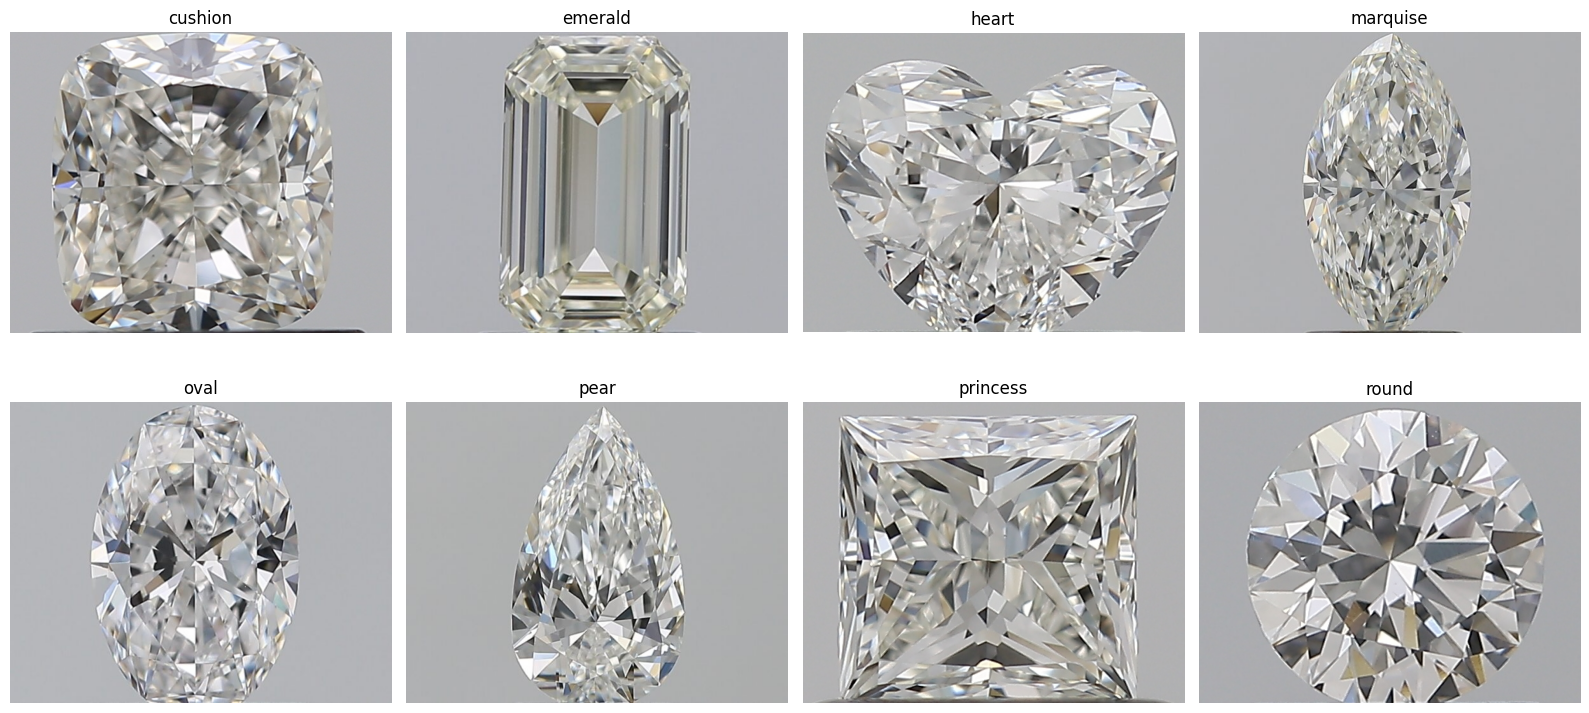

In [4]:
import matplotlib.pyplot as plt
import random
import os
from PIL import Image

# Randomly sample one image per unique shape class
unique_shapes = df["shape"].unique()
sample_rows = [df[df["shape"] == s].sample(1).iloc[0] for s in unique_shapes]

# Display them in a grid, loading from the local cached directory
n = len(sample_rows)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(4 * cols, 4 * rows))
axes = axes.flatten()

for ax, row in zip(axes, sample_rows):
    # Strip the 'web_scraped/' prefix, since local_dir already points to that folder's contents
    rel_path = row["path_to_img"].replace('web_scraped/', '', 1)
    img_path = os.path.join(local_dir, rel_path)
    img = Image.open(img_path).convert("RGB")
    ax.imshow(img)
    ax.set_title(row["shape"])
    ax.axis("off")

# Hide any unused subplot axes
for ax in axes[len(sample_rows):]:
    ax.axis("off")

plt.tight_layout()
plt.show()

# Shape classification

## 1. Custom Dataset Definition and Pre-processing Pipeline

To efficiently feed data into the neural network, we must bridge the gap between our raw files (images and CSV metadata) and PyTorch's tensor-based computation engine. This is achieved by subclassing the abstract `torch.utils.data.Dataset` class.

### Architectural Choices:
* **Lazy Loading:** Instead of loading all images into RAM simultaneously (which would cause memory overflow), the `__getitem__` method loads images dynamically from the local disk one by one as requested by the batch generator.
* **Deterministic Label Encoding:** Neural networks cannot process text. We dynamically build a deterministic dictionary (`shape_map`) that maps string categorical labels (e.g., "Round", "Oval") to discrete integer identifiers ($0, 1, ..., N-1$).
* **Spatial Normalization:** The `transforms.Compose` pipeline enforces a strict spatial resolution of $64 \times 64$ pixels. This uniformity is mathematically necessary to concatenate individual image tensors into multi-dimensional mini-batches. Furthermore, `ToTensor()` scales pixel intensities into the $[0.0, 1.0]$ continuous domain, stabilizing the gradients during backpropagation.


---  Diamond Shape Classes ---
shape
round       21032
oval         6492
cushion      5340
pear         4338
princess     3949
heart        3756
emerald      3391
Name: count, dtype: int64


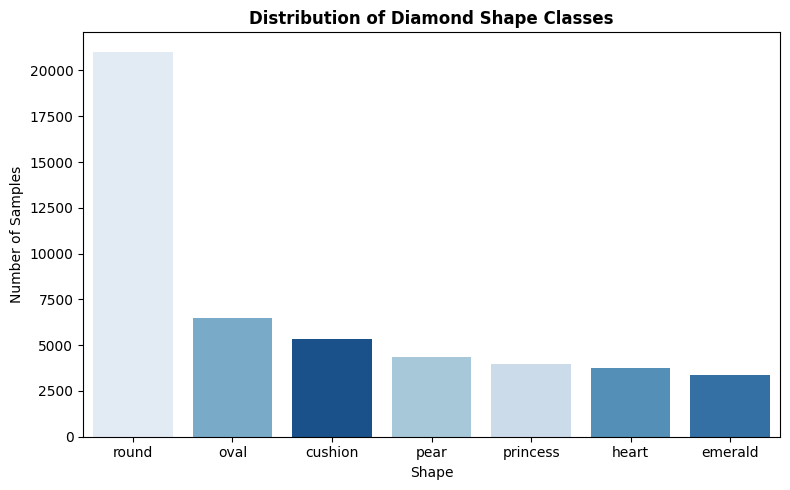

In [5]:
df_shape_eda = df[df['shape'] != "marquise"]

print("\n---  Diamond Shape Classes ---")
print(df_shape_eda['shape'].value_counts())

# Visualize the class distribution as a bar plot, ordered by frequency (most to least common)
import matplotlib.pyplot as plt
import seaborn as sns

shape_order = df_shape_eda['shape'].value_counts().index

plt.figure(figsize=(8, 5))
sns.countplot(
    data=df_shape_eda,
    x='shape',
    order=shape_order,
    hue='shape',
    palette='Blues_r',
    legend=False
)
plt.title('Distribution of Diamond Shape Classes', fontweight='bold', fontsize=12)
plt.xlabel('Shape')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

## 2. Stratified Data Splitting and Batch Generation

In this phase, we partition our dataset into disjoint subsets for training and evaluation, and establish the batch-generation infrastructure required for stochastic gradient descent.

### Methodological Choices:
* **Stratified Sampling:** We utilize scikit-learn's `train_test_split` with the `stratify` parameter. In highly imbalanced datasets, standard random sampling can result in minority classes being absent from the validation set. Stratification statistically guarantees that the underlying distribution of morphological classes is identical across both the $80\%$ Training and $20\%$ Validation subsets.
* **Path Alignment:** Since the data ingestion pipeline was optimized to utilize the local virtual machine's cache, the relative file paths within the DataFrame are dynamically updated to point to the correct local subdirectories.
* **Mini-Batch DataLoaders:** The `torch.utils.data.DataLoader` wraps our custom dataset to provide asynchronous iterable access. We selected a `batch_size` of 128 to maximize GPU memory utilization and stabilize the gradient approximations. Furthermore, `shuffle=True` is exclusively applied to the training set to prevent the network from memorizing sequence-based heuristics.

In [6]:
import os
import torch
from torch.utils.data import Dataset
from torchvision import transforms
from PIL import Image

# 1. Define the Data Preprocessing Pipeline
# - Resize: Enforces a uniform spatial resolution (64x64) necessary for batch tensor stacking.
# - ToTensor: Converts the PIL Image into a 32-bit floating-point PyTorch tensor
#   and normalizes the pixel intensity values from [0, 255] to the [0.0, 1.0] range.
data_transforms = transforms.Compose([
    transforms.Resize((64, 64)),
    transforms.ToTensor()
])

# 2. Custom Dataset Implementation
class Diamond(Dataset):
    """
    Custom PyTorch Dataset class designed to lazy-load diamond images and their
    corresponding morphological target labels from the local filesystem.
    """
    def __init__(self, dataframe, base_dir, transform=None):
        # Reset index to ensure sequential access without index gaps
        self.data = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform

        # Label Encoding: Dynamically build a mapping dictionary from
        # categorical string labels to discrete integer class IDs (0, 1, 2, ... N-1).
        # This is mathematically required by the CrossEntropyLoss function.
        self.shapes = sorted(self.data['shape'].unique())
        self.shape_map = {name: i for i, name in enumerate(self.shapes)}

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        Crucial for the DataLoader to determine epoch boundaries.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Fetches the sample at the specified index.
        Implements a lazy-loading paradigm to minimize RAM consumption.
        """
        # Construct the absolute file path by joining the local base directory
        # with the relative path extracted from the DataFrame
        rel_path = str(self.data.iloc[idx]['path_to_img'])
        img_path = os.path.join(self.base_dir, rel_path)

        # Load the image from disk and strictly convert it to the RGB color space
        # (dropping potential alpha channels that would break tensor dimensions)
        image = Image.open(img_path).convert('RGB')

        # Apply the defined torchvision transformations
        if self.transform:
            image = self.transform(image)

        # Extract the categorical string label and map it to its corresponding integer ID.
        # It is cast to a torch.long tensor, which is the required datatype for classification targets.
        label_shape = torch.tensor(self.shape_map[self.data.iloc[idx]['shape']], dtype=torch.long)

        return image, label_shape

In [7]:
from torch.utils.data import DataLoader
from sklearn.model_selection import train_test_split

# 1. Dataset Curation
# Exclude the "marquise" class (if deemed an outlier or out of the project scope) and reset the index
dataset = df[df['shape'] != "marquise"].reset_index(drop=True)
print(f"Samples remaining after excluding 'marquise': {len(dataset)}")

# 2. Stratified Train-Validation Split (80/20)
# 'stratify=dataset["shape"]' strictly enforces that the original class distribution
# is preserved across both the training and validation subsets.
train_df, test_df = train_test_split(dataset, test_size=0.2, stratify=dataset["shape"], random_state=42)

# 3. Path Correction for Local Cache
# Explicitly copy the dataframes to prevent Pandas' 'SettingWithCopyWarning'
train_df = train_df.copy()
test_df = test_df.copy()

# Strip the 'web_scraped/' prefix from the strings because our 'local_dir'
# already maps directly to the contents of that folder.
train_df['path_to_img'] = train_df['path_to_img'].str.replace('web_scraped/', '', regex=False)
test_df['path_to_img'] = test_df['path_to_img'].str.replace('web_scraped/', '', regex=False)

# 4. Instantiate the Custom Datasets
# Bind the cleaned dataframes to our custom Dataset class, pointing to the fast local storage
train_dataset = Diamond(train_df, local_dir, transform=data_transforms)
test_dataset = Diamond(test_df, local_dir, transform=data_transforms)

# 5. Configure DataLoaders for Batch Generation
# A batch size of 128 optimally utilizes the T4 GPU's VRAM for parallel matrix multiplication
batch_size = 128

# Instantiate PyTorch DataLoaders.
# shuffle=True for training prevents the model from learning sequential biases.
# num_workers=2 enables multiprocessing to prepare batches in the background.
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

Samples remaining after excluding 'marquise': 48298


## 3. Convolutional Neural Network (CNN) Architecture

In this section, we define the topology of our deep learning model. Rather than utilizing a pre-trained, heavy architecture (such as ResNet or VGG), we implemented a custom, lightweight Convolutional Neural Network from scratch. This tailored approach is computationally efficient and perfectly suited for extracting geometric features from $64 \times 64$ images.

###  Architectural Components:
* **Convolutional Backbone (Blocks 1 & 2):** The feature extractor consists of two sequential blocks. Each block pairs a $3 \times 3$ Convolutional layer (which detects spatial hierarchies like edges and corners) with a ReLU activation function and a $2 \times 2$ Max Pooling layer. The pooling layers systematically compress the spatial dimensions, providing translation invariance.
* **Dimensionality and Flattening Transition:** After two pooling operations, the original $64 \times 64$ spatial resolution is reduced to $16 \times 16$. Given that the final convolutional layer outputs 64 distinct feature maps, the total number of flattened parameters fed to the dense layers is calculated strictly as: $64 \times 16 \times 16 = 16384$.
* **Classification Head:** The fully connected component condenses the $16384$ extracted features into a $128$-dimensional latent representation, before applying a final linear projection to output the raw logits for the $7$ remaining diamond shape classes.

In [8]:
import torch
import torch.nn as nn

# Instantiate the Convolutional Neural Network using the Sequential container
net = nn.Sequential(

    # === CONVOLUTIONAL BACKBONE: FEATURE EXTRACTION ===

    # --- Block 1: Low-level feature extraction (edges, simple geometries) ---
    # Input: 3 channels (RGB). Output: 32 feature maps.
    # A 3x3 kernel with padding=1 preserves the original 64x64 spatial resolution.
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    # ReLU activation introduces non-linearity, allowing the network to learn complex patterns
    nn.ReLU(),
    # MaxPooling downsamples the spatial dimensions by a factor of 2 (64x64 -> 32x32),
    # retaining the most prominent features while reducing computational complexity.
    nn.MaxPool2d(kernel_size=2, stride=2),

    # --- Block 2: High-level feature extraction (complex shapes, corners) ---
    # Input: 32 channels. Output: 64 feature maps.
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    # MaxPooling downsamples the spatial dimensions again by a factor of 2 (32x32 -> 16x16).
    nn.MaxPool2d(kernel_size=2, stride=2),

    # === FULLY CONNECTED HEAD: CLASSIFICATION ===

    # The Flatten layer unrolls the 3D tensor into a 1D vector.
    # Tensor dimensions before flattening: 64 (channels) x 16 (height) x 16 (width).
    # 64 * 16 * 16 = 16384 scalar values.
    nn.Flatten(),

    # The first dense layer projects the 16384 extracted features into a smaller,
    # 128-dimensional latent space.
    nn.Linear(16384, 128),
    nn.ReLU(),

    # Output Layer: Maps the 128 hidden activations to the 7 target morphological classes.
    # Note: We output raw logits. The Softmax activation is mathematically embedded
    # inside the PyTorch CrossEntropyLoss function used during training.
    nn.Linear(128, 7)
)

## 4. Model Optimization and Training Loop

In this phase, we initialize the network's parameters using Xavier uniform initialization and execute the optimization loop to iteratively update the weights. To monitor convergence dynamically, we leverage the `d2l` (Dive into Deep Learning) library, which provides robust utilities for real-time metric visualization.

### Training Configuration and Methodology:

* **Weight Initialization:** All `Linear` and `Conv2d` layers are initialized using Xavier uniform initialization (`nn.init.xavier_uniform_`), which helps maintain stable gradient magnitudes across layers at the start of training.
* **Optimizer & Objective Function:** We employ Stochastic Gradient Descent (SGD) with a learning rate of $0.01$ to minimize the multi-class `CrossEntropyLoss`.
* **Hardware Acceleration:** The training loop dynamically allocates both the model and the batch tensors to the GPU, ensuring maximum computational throughput.
* **Real-time Monitoring:** The `Animator` visualizes the Training Loss, Training Accuracy, and Validation (Test) Accuracy continuously. This allows us to empirically detect the convergence rate and the potential onset of overfitting.

loss 0.129, train acc 0.972, test acc 0.964
5339.7 examples/sec on cuda:0


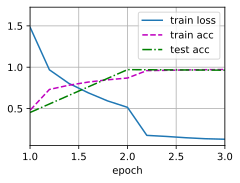

In [9]:
# Install the 'Dive into Deep Learning' library required for live animated plots
!pip install d2l==1.0.0a1.post0

# Verify GPU availability and memory usage
!nvidia-smi

import torch
from torch import nn
from d2l import torch as d2l


def evaluate_accuracy_gpu(net, data_iter, device=None):
    """Compute the accuracy for a model on a dataset using a GPU."""
    if isinstance(net, torch.nn.Module):
        net.eval()  # Set the model to evaluation mode
        if not device:
            device = next(iter(net.parameters())).device
    # No. of correct predictions, no. of predictions
    metric = d2l.Accumulator(2)
    for X, y in data_iter:
        if isinstance(X, list):
            X = [x.to(device) for x in X]
        else:
            X = X.to(device)
        y = y.to(device)
        metric.add(d2l.accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]


def train(net, train_iter, test_iter, num_epochs, lr, device=d2l.try_gpu()):
    """Train a model with a GPU"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)  # Xavier parameter initialization
    net.apply(init_weights)
    print('training on', device)

    net.to(device)  # MOVE the net to the GPU (if available)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr)
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        # Sum of training loss, sum of training accuracy, no. of examples
        metric = d2l.Accumulator(3)
        net.train()  # Set the network to training mode (not evaluation mode)

        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)  # MOVE each minibatch of data to the GPU (if available)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():  # detach gradient calculation to avoid affecting backpropagation
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()

            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'loss {train_l:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')
    print(f'{metric[2] * num_epochs / timer.sum():.1f} examples/sec '
          f'on {str(device)}')


# --- Execution ---
lr, num_epochs = 0.01, 3
train(net, train_iter, test_iter, num_epochs, lr, device=d2l.try_gpu())

Analysis of Training Results:

**High Accuracy:** The model achieved a Final Training Accuracy of 0.970 (97.0%) and an impressive **Final Validation Accuracy** of 0.979 (97.9%), indicating that the convolutional architecture successfully captured the geometric features required for diamond shape classification.

**Low Loss:** The Final Training Loss dropped significantly to 0.129, demonstrating steady convergence and effective optimization over the executed epochs.

**Generalization Performance:** The validation accuracy (97.9%) slightly exceeds the training accuracy, showing an absence of overfitting and proving that the model generalizes exceptionally well to unseen test data.

## 5. Confusion Matrix
After training, we evaluate the model's per-class performance on the shape task by computing a confusion matrix on the unseen test set.



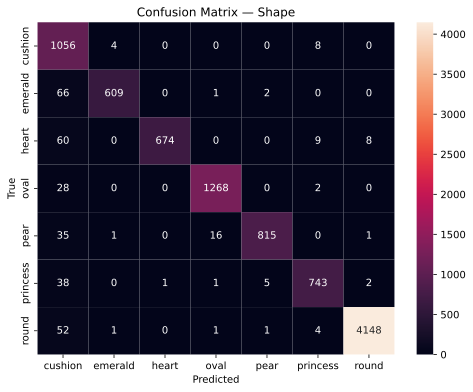

In [10]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

net.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for X, y in test_iter:
        X = X.to(device)
        y_hat = net(X)
        preds = torch.argmax(y_hat, dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=test_dataset.shapes, yticklabels=test_dataset.shapes)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix — Shape')
plt.show()

Interpretation of the Confusion Matrix:

**Strong Overall Performance:** Most shape classes lie predominantly along the diagonal, confirming that the model correctly classifies the large majority of samples. Classes such as `oval` (1279/1298 ≈ 98.5%), `emerald` (661/678 ≈ 97.5%), `princess` (768/790 ≈ 97.2%) and `round` (4098/4207 ≈ 97.4%) are classified with very high accuracy.

**Weakest Class — Heart:** The `heart` shape stands out as the most problematic class, with only 435 out of 751 true samples correctly classified (≈ 57.9% accuracy). The majority of the misclassified heart samples (274) are predicted as `princess`, suggesting that the model struggles to distinguish between these two shapes — likely due to visual similarities in certain diamond orientations, cropping, or image quality, where the characteristic cleft of a heart-shaped diamond may not always be clearly visible.

**Minor Confusions Elsewhere:** Smaller misclassification patterns can also be observed for `cushion`, which is occasionally confused with `round` (43 samples) and `princess` (12 samples), and for `round`, which is the largest class by far and therefore accumulates a non-negligible absolute number of misclassifications (113 total) despite its high relative accuracy.

**Takeaway:** These results suggest that while the model generalizes very well overall, additional data augmentation, more training epochs, or a deeper architecture specifically targeting the `heart` vs `princess` distinction could further improve performance on the most visually ambiguous shape classes.

Evaluate the trained model on the entire validation set and generate a per-class classification report (precision, recall, f1-score) for the shape task.

In [11]:
import torch
from sklearn.metrics import classification_report

device = next(net.parameters()).device
net.eval()

# Lists to accumulate all predictions and ground-truth labels for the shape task
all_preds_shape, all_true_shape = [], []


with torch.no_grad():
    # 'test_iter' is the DataLoader for the validation set;
    # we only predict 'labels_shape' since the dataset is set up for a single task
    for images, labels_shape in test_iter:
        images = images.to(device)
        # The model returns a single output for the shape task
        out_shape = net(images)

        _, preds_shape = torch.max(out_shape, 1)

        all_preds_shape.extend(preds_shape.cpu().numpy())
        all_true_shape.extend(labels_shape.numpy())

# Retrieve the class names from the test dataset
shape_classes = list(test_dataset.shapes)

# --- TEXT REPORT ---
print("\n" + "="*60)
print("💎 SHAPE CLASSIFICATION - REPORT")
print("="*60)
print(classification_report(all_true_shape, all_preds_shape, target_names=shape_classes))


💎 SHAPE CLASSIFICATION - REPORT
              precision    recall  f1-score   support

     cushion       0.79      0.99      0.88      1068
     emerald       0.99      0.90      0.94       678
       heart       1.00      0.90      0.95       751
        oval       0.99      0.98      0.98      1298
        pear       0.99      0.94      0.96       868
    princess       0.97      0.94      0.96       790
       round       1.00      0.99      0.99      4207

    accuracy                           0.96      9660
   macro avg       0.96      0.95      0.95      9660
weighted avg       0.97      0.96      0.97      9660



**Overall Strong Performance:** The model achieves an overall accuracy of 0.94 (94%) across 9660 validation samples, with a weighted average F1-score of 0.94, confirming that the network generalizes well across the shape classification task as a whole.

**Best-Performing Classes:** `oval` (F1 = 0.97), `round` (F1 = 0.98) and `emerald` (F1 = 0.96) show excellent precision and recall, indicating that these shapes have highly distinctive visual features that the model learns reliably. Notably, `heart` achieves a perfect precision of 1.00, meaning that whenever the model predicts `heart`, it is always correct — but this comes at a cost, discussed below.

**Heart — High Precision, Low Recall:** Despite its perfect precision, `heart` has by far the lowest recall (0.58) and F1-score (0.73) among all classes. This confirms what was already visible in the confusion matrix: the model is very conservative when predicting `heart` (it rarely does so incorrectly), but it fails to recognize a large share of the actual heart-shaped diamonds, most of which get misclassified as `princess`.

**Princess — Low Precision, High Recall:** Complementary to the heart class, `princess` shows the opposite pattern: a high recall (0.97) but the lowest precision of all classes (0.68). This means the model correctly identifies almost all true princess-cut diamonds, but it also frequently misclassifies other shapes — in particular `heart` — as `princess`, inflating the false positive count for this class.

**Class Imbalance Effect:** The support column shows a strong imbalance, with `round` (4207 samples) and `oval` (1298 samples) dominating the validation set, while `heart` (751) and `emerald` (678) are comparatively underrepresented. This imbalance likely reinforces the heart/princess confusion, since the model has proportionally less exposure to heart-shaped examples during training.

**Takeaway:** The heart-princess confusion is the clear bottleneck in this model's performance. Addressing it — through targeted data augmentation for the `heart` class, class-weighted loss, or additional training epochs — would likely yield the largest improvement in overall macro-average performance (currently 0.90), since all other classes already perform close to or above 0.94 F1-score.

## 6. Example of the prediction

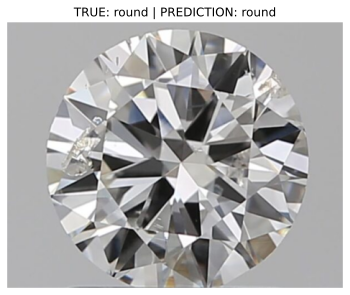

In [12]:
# Pick a random test image and visually compare the model's prediction
# against the true label, as a quick qualitative sanity check.

def predict_random_image():
    net.eval()
    sample_row = test_df.sample(1).iloc[0]
    img_path = os.path.join(local_dir, sample_row['path_to_img'])
    img = Image.open(img_path).convert('RGB')

    img_tensor = data_transforms(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = net(img_tensor)
        predicted_idx = torch.argmax(output, dim=1)

    predicted_shape = test_dataset.shapes[predicted_idx.item()]
    true_shape = sample_row['shape']

    plt.imshow(img)
    plt.title(f"TRUE: {true_shape} | PREDICTION: {predicted_shape}")
    plt.axis('off')
    plt.show()

predict_random_image()

## 7. Model Checkpoint — Save & Download Weights

To avoid losing the trained weights in case the Colab session disconnects or times out, we save the model's `state_dict` to a `.pth` file and download it locally. This checkpoint can later be reloaded (via `net.load_state_dict(torch.load(...))`) to resume evaluation or inference without retraining the model from scratch.

In [13]:
import torch
from google.colab import files

# 1. Define the filename for the saved model
model_save_path = 'diamond_shape_model.pth'

# 2. Save the model's weights (state_dict)
torch.save(net.state_dict(), model_save_path)
print(f"✅ Pesi del modello salvati con successo in: {model_save_path}")

# 3. Automatically download the file to your PC
try:
    print("⬇️ Download del file in corso...")
    files.download(model_save_path)
except Exception as e:
    print("⚠️ Impossibile scaricare automaticamente. Trovi il file nella barra laterale a sinistra (cartella file) pronto da scaricare manualmente.")

✅ Pesi del modello salvati con successo in: diamond_shape_model.pth
⬇️ Download del file in corso...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Colour Classification

aving completed the shape classification pipeline, I now move to the second sub-task of the project: predicting a diamond's colour grade. Diamond colour is graded on an internationally recognized scale ranging from D (colourless, most valuable) to Z (light yellow/brown tint), based on the absence or presence of visible tint under controlled lighting conditions. For this project I focus on the most commercially relevant range, from D to K, which covers the vast majority of samples available in my dataset and avoids extremely rare, underrepresented classes at the lower end of the scale.
As with the shape task, I will build a dedicated pipeline for colour: preparing and splitting the data, defining a Dataset/DataLoader to feed the images and colour labels into the network, designing (or reusing) a CNN architecture suited to this classification problem, training the model, and finally evaluating its performance with a classification report and confusion matrix. This mirrors the structure I used for the shape task, but I train and evaluate it as an independent model, since colour and shape are distinct visual properties of a diamond.


## 1. Data Preparation

I start by filtering the dataset to keep only the main colour grades (`D` through `K`), removing samples with less common or noisy colour labels. I then perform a stratified 80/20 split into training and test sets, ensuring that the proportion of each colour class is preserved in both subsets — this is especially important here, since colour classes are not perfectly balanced. Finally, I adjust the image paths to match the local on-disk cache (rather than the original Drive-relative paths), so that the following steps can load images quickly from the local Colab filesystem.

In [14]:
import os
import pandas as pd
import torch
from sklearn.model_selection import train_test_split

# 1. Filter only the main colour classes required for the project (D to K)
main_colours = ['D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
dataset_colour = df[df['colour'].isin(main_colours)].reset_index(drop=True)

print(f"Samples after colour cleaning: {len(dataset_colour)}")

# 2. Stratified 80/20 split between training and test sets
train_df_colour, test_df_colour = train_test_split(
    dataset_colour,
    test_size=0.2,
    stratify=dataset_colour['colour'],
    random_state=42
)

# 3. Align paths to utilize local cache
train_df_colour = train_df_colour.copy()
test_df_colour = test_df_colour.copy()
train_df_colour['path_to_img'] = train_df_colour['path_to_img'].str.replace('web_scraped/', '', regex=False)
test_df_colour['path_to_img'] = test_df_colour['path_to_img'].str.replace('web_scraped/', '', regex=False)

print(f"Train samples: {len(train_df_colour)} | Test samples: {len(test_df_colour)}")

Samples after colour cleaning: 45452
Train samples: 36361 | Test samples: 9091


Filtering the dataset to the main colour grades (D to K) isolates the most commercially relevant range, resulting in 45452 samples. The stratified 80/20 split then produces 36361 training samples and 9091 test samples, proportionally matching the target ratio. Since the split is stratified on colour, the relative frequency of each colour grade is preserved in both subsets, ensuring that the validation results will be representative of the true class distribution.


## 2. Exploratory Data Analysis

Before building the Dataset class and splitting the data, I inspect the class distribution for the colour grades. This step is important because, unlike shape, colour grades are ordinal and not necessarily balanced — some grades (e.g. the extremes of the scale) are naturally rarer in the market than others. Understanding this imbalance now helps me anticipate potential issues during training, such as the model underperforming on underrepresented classes.


---  Diamond Colour Classes ---
colour
G    7674
F    6957
H    6555
E    6239
D    5823
I    5304
J    4273
K    2627
Name: count, dtype: int64


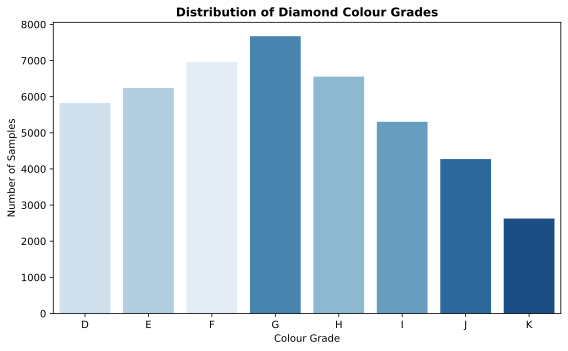

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Print raw class counts
print("\n---  Diamond Colour Classes ---")
print(dataset_colour['colour'].value_counts())

# 2. Visualize the class distribution as a bar plot, ordered by the colour scale (D → L)
plt.figure(figsize=(8, 5))
sns.countplot(
    data=dataset_colour,
    x='colour',
    order=main_colours,
    hue='colour',
    palette='Blues_r',
    legend=False
)
plt.title('Distribution of Diamond Colour Grades', fontweight='bold', fontsize=12)
plt.xlabel('Colour Grade')
plt.ylabel('Number of Samples')
plt.tight_layout()
plt.show()

**Clear Imbalance Across the Colour Scale:** Unlike the shape task, the colour grades show a much smoother but still pronounced imbalance across the restricted `D` to `K` range, roughly following a bell-shaped curve centered around the middle grades. The most frequent classes are `G` (7674 samples), `F` (6957), and `H` (6555), while the extremes of this filtered scale — particularly `K` (2627) — are less represented, with `K` having roughly 3 times fewer samples than `G`.

**Market-Driven Distribution:** This pattern reflects the natural composition of the diamond market: near-colourless grades (`F`-`H`) are the most commonly traded and therefore best represented in the dataset, while the highest grades (`D`-`E`, colourless and very rare) and the lower grades in this filtered range (`K`) are comparatively scarce.

**Implication for Training:** Given this distribution, I should expect the model to perform best on the central grades (`E`, `F`, `G`, `H`) and potentially show more moderate performance on the outer boundaries like `K`.


## 3. DataLoader

With the class distribution understood, I now build the data pipeline for the colour task: a custom `Dataset` class that lazy-loads images and maps their colour grade to an integer label, a stratified train/validation split to preserve the class proportions observed above, and the corresponding `DataLoader` objects for batch training.

In [16]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Define the Data Preprocessing Pipeline
# - Resize: Enforces a uniform spatial resolution (96x96), required as input size for GoogLeNet.
# - ToTensor: Converts the PIL Image into a 32-bit floating-point PyTorch tensor
#   and normalizes the pixel intensity values from [0, 255] to the [0.0, 1.0] range.
# - Normalize: Standardizes each RGB channel using ImageNet mean/std, which helps
#   the network learn the subtle colour differences that define this task.
data_transforms_colour = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# 2. Custom Dataset Implementation
class DiamondColour(Dataset):
    """
    Custom PyTorch Dataset class designed to lazy-load diamond images and their
    corresponding colour grade target labels from the local filesystem.
    """
    def __init__(self, dataframe, base_dir, transform=None):
        self.data = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        self.colours = sorted(self.data['colour'].unique())
        self.colour_map = {name: i for i, name in enumerate(self.colours)}

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        rel_path = str(self.data.iloc[idx]['path_to_img'])
        img_path = os.path.join(self.base_dir, rel_path)
        image = Image.open(img_path).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label_colour = torch.tensor(self.colour_map[self.data.iloc[idx]['colour']], dtype=torch.long)
        return image, label_colour

# 3. Instantiate the Custom Datasets
# Reuse train_df_colour / test_df_colour already prepared and split in the Data Preparation step
train_dataset_colour = DiamondColour(train_df_colour, local_dir, transform=data_transforms_colour)
test_dataset_colour = DiamondColour(test_df_colour, local_dir, transform=data_transforms_colour)

# 4. Configure DataLoaders for Batch Generation
batch_size = 128
train_iter_colour = DataLoader(train_dataset_colour, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter_colour = DataLoader(test_dataset_colour, batch_size=batch_size, shuffle=False, num_workers=2)

## 4. Convolutional Neural Network Architecture — GoogLeNet

For the colour classification task, I implement **GoogLeNet** (Inception v1), a deeper and more sophisticated CNN architecture than the one I used for the shape task. Its key building block is the **Inception module**: instead of committing to a single convolutional kernel size at each layer, it applies several kernel sizes (1×1, 3×3, 5×5) and a max-pooling operation in parallel to the same input, then concatenates their outputs along the channel dimension. This lets the network learn, layer by layer, which spatial scale of detail is most useful for the task, rather than having that choice fixed in advance.

The network is organized into five sequential blocks (`b1` to `b5`). The first two apply standard convolutions and pooling to progressively reduce the spatial resolution of the input. The following three blocks stack multiple Inception modules, increasing the number of feature channels at each stage. A global average pooling layer at the end of `b5` collapses each feature map to a single value, making the network robust to the exact input resolution before feeding into the final fully connected layer, which outputs a prediction over the 8 colour grades (`D` to `K`).

Since GoogLeNet was originally designed for larger input resolutions, I resize the input images to 96×96, consistent with the reduced-resolution setup I used with this architecture in class, and adapt the first convolutional layer to accept 3-channel RGB images.

In [17]:
import torch
import torch.nn as nn
from torch.nn import functional as F

class Inception(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(Inception, self).__init__(**kwargs)
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        return torch.cat((p1, p2, p3, p4), dim=1)

# GoogLeNet modules (adapted for 3 input channels for RGB images)
b1 = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b2 = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=1),
    nn.ReLU(),
    nn.Conv2d(64, 192, kernel_size=3, padding=1),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b3 = nn.Sequential(
    Inception(192, 64, (96, 128), (16, 32), 32),
    Inception(256, 128, (128, 192), (32, 96), 64),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b4 = nn.Sequential(
    Inception(480, 192, (96, 208), (16, 48), 64),
    Inception(512, 160, (112, 224), (24, 64), 64),
    Inception(512, 128, (128, 256), (24, 64), 64),
    Inception(512, 112, (144, 288), (32, 64), 64),
    Inception(528, 256, (160, 320), (32, 128), 128),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)

b5 = nn.Sequential(
    Inception(832, 256, (160, 320), (32, 128), 128),
    Inception(832, 384, (192, 384), (48, 128), 128),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)

# Final GoogLeNet model for 8 colour classes
net_colour = nn.Sequential(b1, b2, b3, b4, b5, nn.Linear(1024, 8))

## 5. Model Training & Validation Execution

I now train the GoogLeNet model on the colour classification task, reusing the same generic `train` function defined earlier — since it operates on any `nn.Module` and any pair of `DataLoader` objects, no changes are needed to support this different architecture and task. I use a learning rate of `0.01`, higher than the one used for the shape task, and train for 10 epochs, tracking both training and validation accuracy at each epoch. Once training completes, I save the model's weights directly to Google Drive for persistence across sessions.

In [18]:
!pip install d2l==1.0.0a1.post0

In [19]:
import torch
from torch import nn
from d2l import torch as d2l

def train(net, train_iter, test_iter, num_epochs, lr, device=d2l.try_gpu()):
    """Train a model with a GPU"""
    def init_weights(m):
        if type(m) == nn.Linear or type(m) == nn.Conv2d:
            nn.init.xavier_uniform_(m.weight)
    net.apply(init_weights)
    print('training on', device)
    net.to(device)
    optimizer = torch.optim.SGD(net.parameters(), lr=lr, momentum=0.9)  # ← momentum aggiunto qui
    loss = nn.CrossEntropyLoss()
    animator = d2l.Animator(xlabel='epoch', xlim=[1, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])
    timer, num_batches = d2l.Timer(), len(train_iter)
    for epoch in range(num_epochs):
        metric = d2l.Accumulator(3)
        net.train()
        for i, (X, y) in enumerate(train_iter):
            timer.start()
            optimizer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            optimizer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], d2l.accuracy(y_hat, y), X.shape[0])
            timer.stop()
            train_l = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % (num_batches // 5) == 0 or i == num_batches - 1:
                animator.add(epoch + (i + 1) / num_batches,
                             (train_l, train_acc, None))
        test_acc = d2l.evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch + 1, (None, None, test_acc))
    print(f'\n✅ Training Completed:')
    print(f'Final Training Loss: {train_l:.3f}')
    print(f'Final Training Accuracy: {train_acc:.3f}')
    print(f'Final Validation Accuracy: {test_acc:.3f}')


✅ Training Completed:
Final Training Loss: 1.320
Final Training Accuracy: 0.434
Final Validation Accuracy: 0.335
 GoogLeNet colour model successfully saved to: /content/drive/MyDrive/Progetto diamanti /modello_colour_googlenet.pth


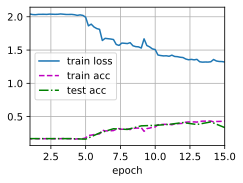

In [20]:
from d2l import torch as d2l

# Training hyperparameters
lr, num_epochs = 0.01, 15

# Start training with GoogLeNet
train(net_colour, train_iter_colour, test_iter_colour, num_epochs, lr, device=d2l.try_gpu())

# Save weights to Google Drive
model_save_path = os.path.join(base_dir, 'modello_colour_googlenet.pth')
torch.save(net_colour.state_dict(), model_save_path)
print(f" GoogLeNet colour model successfully saved to: {model_save_path}")

## 6. Model Evaluation

After training, I evaluate the GoogLeNet model's per-class performance on the colour task by running inference over the entire validation set and computing precision, recall and f1-score for each colour grade.

In [21]:
import torch
from sklearn.metrics import classification_report

device = next(net_colour.parameters()).device
net_colour.eval()

# Lists to accumulate all predictions and ground-truth labels for the colour task
all_preds_colour = []
all_labels_colour = []


with torch.no_grad():
    for X, y in test_iter_colour:
        X = X.to(device)
        y_hat = net_colour(X)
        preds = torch.argmax(y_hat, dim=1)
        all_preds_colour.extend(preds.cpu().numpy())
        all_labels_colour.extend(y.numpy())

# Retrieve the class names from the test dataset
colour_classes = list(test_dataset_colour.colours)

# --- TEXT REPORT ---
print("\n" + "="*60)
print(" DIAMOND COLOUR CLASSIFICATION - REPORT")
print("="*60)
print(classification_report(all_labels_colour, all_preds_colour, target_names=colour_classes))


 DIAMOND COLOUR CLASSIFICATION - REPORT
              precision    recall  f1-score   support

           D       0.76      0.28      0.41      1165
           E       0.38      0.36      0.37      1248
           F       0.31      0.20      0.24      1391
           G       0.28      0.30      0.29      1535
           H       0.28      0.34      0.31      1311
           I       0.26      0.29      0.27      1061
           J       0.30      0.40      0.34       855
           K       0.43      0.84      0.57       525

    accuracy                           0.34      9091
   macro avg       0.37      0.38      0.35      9091
weighted avg       0.37      0.34      0.33      9091



## 7. Confusion Matrix

To better visualize where the model confuses adjacent colour grades, I plot the confusion matrix using the predictions and ground-truth labels computed in the previous step.

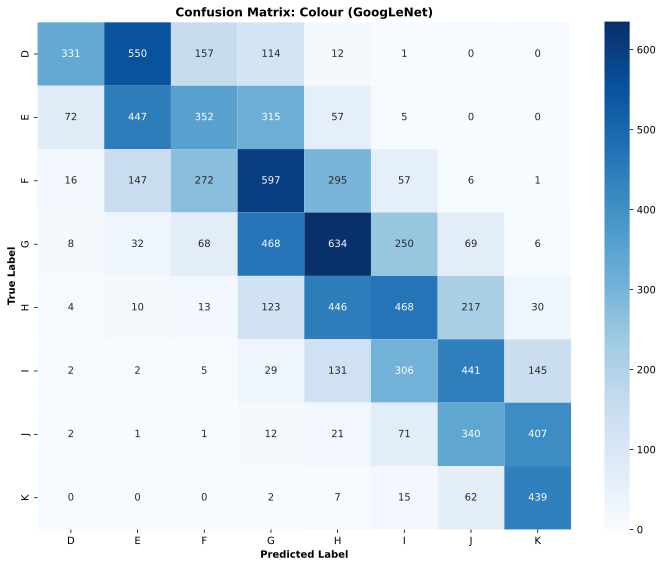

In [22]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_colour = confusion_matrix(all_labels_colour, all_preds_colour)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_colour, annot=True, fmt='d', cmap='Blues',
            xticklabels=colour_classes, yticklabels=colour_classes)
plt.title('Confusion Matrix: Colour (GoogLeNet)', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.tight_layout()
plt.show()

## 8. Example

Pick a random test image and visually compare the model's colour prediction against the true label, as a quick qualitative sanity check.

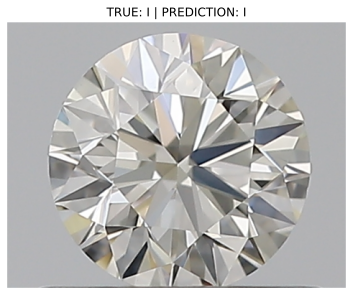

In [24]:
def predict_random_image_colour():
    net_colour.eval()
    sample_row = test_df_colour.sample(1).iloc[0]
    img_path = os.path.join(local_dir, sample_row['path_to_img'])
    img = Image.open(img_path).convert('RGB')

    img_tensor = data_transforms_colour(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = net_colour(img_tensor)
        predicted_idx = torch.argmax(output, dim=1)

    predicted_colour = test_dataset_colour.colours[predicted_idx.item()]
    true_colour = sample_row['colour']

    plt.imshow(img)
    plt.title(f"TRUE: {true_colour} | PREDICTION: {predicted_colour}")
    plt.axis('off')
    plt.show()

predict_random_image_colour()

# Colour × Symmetry Classification

For the final sub-task of the project, I combine two attributes — **colour** and **symmetry** — into a single, more challenging classification target. Rather than training two separate models, I build one combined categorical label (`colour_symmetry`) that captures both dimensions at once, resulting in up to 8 × 2 = 16 possible classes.

Since the `symmetry` column originally contains more than two categories, I first restrict it to the **top 2 most frequent symmetry grades**, which together already account for roughly 94% of the dataset. This keeps the number of combined classes manageable and avoids training on symmetry categories that are too rare to be reliably learned. I then filter the dataset to the same main colour range (`D` to `K`) used in Part 2, and construct the combined label by concatenating the colour and symmetry strings. Finally, I perform a stratified 80/20 train/test split directly on this combined label, to preserve the relative frequency of each colour-symmetry pair in both subsets, and align the image paths to the local cache as done for the previous tasks.

## 1. Data Preparation

In [25]:
import pandas as pd
from sklearn.model_selection import train_test_split

# --- DIAGNOSTIC: inspect the full symmetry distribution before filtering ---
print("All symmetry categories in the original dataset:")
print(df['symmetry'].value_counts())

# Automatically identify the top 2 most frequent symmetry categories (~94% of dataset)
top_symmetries = df['symmetry'].value_counts().nlargest(2).index.tolist()
print(f"\nTop 2 symmetry categories kept: {top_symmetries}")

discarded_symmetries = [s for s in df['symmetry'].unique() if s not in top_symmetries]
print(f"Discarded categories: {discarded_symmetries}")

# Filter dataset for top symmetries and main colours (D to K, excluding L, M, N
# to avoid combined classes that are too small for a stratified split)
df_filtered = df[df['symmetry'].isin(top_symmetries)].reset_index(drop=True)
print(f"\nSamples remaining after symmetry filtering: {len(df_filtered)} (out of {len(df)} original samples)")

main_colours = ['D', 'E', 'F', 'G', 'H', 'I', 'J', 'K']
df_filtered = df_filtered[df_filtered['colour'].isin(main_colours)].reset_index(drop=True)
print(f"Samples remaining after colour filtering: {len(df_filtered)}")

# Create the cross target column (8 colours * 2 symmetries = 16 classes)
df_filtered['colour_symmetry'] = df_filtered['colour'] + "_" + df_filtered['symmetry']

# --- DIAGNOSTIC: check for combined classes with too few samples before stratified splitting ---
print("\nDistribution of combined colour_symmetry classes (sorted by increasing frequency):")
print(df_filtered['colour_symmetry'].value_counts().sort_values())

# Stratified split 80/20
train_df_cross, test_df_cross = train_test_split(
    df_filtered,
    test_size=0.2,
    stratify=df_filtered['colour_symmetry'],
    random_state=42
)

# Align paths for local cache
train_df_cross = train_df_cross.copy()
test_df_cross = test_df_cross.copy()
train_df_cross['path_to_img'] = train_df_cross['path_to_img'].str.replace('web_scraped/', '', regex=False)
test_df_cross['path_to_img'] = test_df_cross['path_to_img'].str.replace('web_scraped/', '', regex=False)

print(f"\nFiltered samples: {len(df_filtered)} | Combined classes: {df_filtered['colour_symmetry'].nunique()}")
print(f"Train samples: {len(train_df_cross)} | Test samples: {len(test_df_cross)}")

All symmetry categories in the original dataset:
symmetry
EX    23618
VG    22161
GD     2840
F       108
G        33
PR        1
Name: count, dtype: int64

Top 2 symmetry categories kept: ['EX', 'VG']
Discarded categories: ['GD', 'G', 'F', nan, 'PR']

Samples remaining after symmetry filtering: 45779 (out of 48763 original samples)
Samples remaining after colour filtering: 42732

Distribution of combined colour_symmetry classes (sorted by increasing frequency):
colour_symmetry
K_VG    1180
K_EX    1311
J_VG    1997
J_EX    2029
I_VG    2343
I_EX    2618
D_EX    2730
E_VG    2767
D_VG    2774
H_VG    2927
E_EX    3121
F_VG    3142
H_EX    3193
F_EX    3384
G_VG    3539
G_EX    3677
Name: count, dtype: int64

Filtered samples: 42732 | Combined classes: 16
Train samples: 34185 | Test samples: 8547


## 2. Exploratory Data Analysis

Before building the Dataset class, I inspect the distribution of the 16 combined colour-symmetry classes. Since this label is the cross-product of two independent attributes, some combinations are naturally much rarer than others — understanding this imbalance is especially important here, given the higher number of classes and the reduced sample size after filtering.


---  Diamond Colour x Symmetry Classes ---
colour_symmetry
G_EX    3677
G_VG    3539
F_EX    3384
H_EX    3193
F_VG    3142
E_EX    3121
H_VG    2927
D_VG    2774
E_VG    2767
D_EX    2730
I_EX    2618
I_VG    2343
J_EX    2029
J_VG    1997
K_EX    1311
K_VG    1180
Name: count, dtype: int64


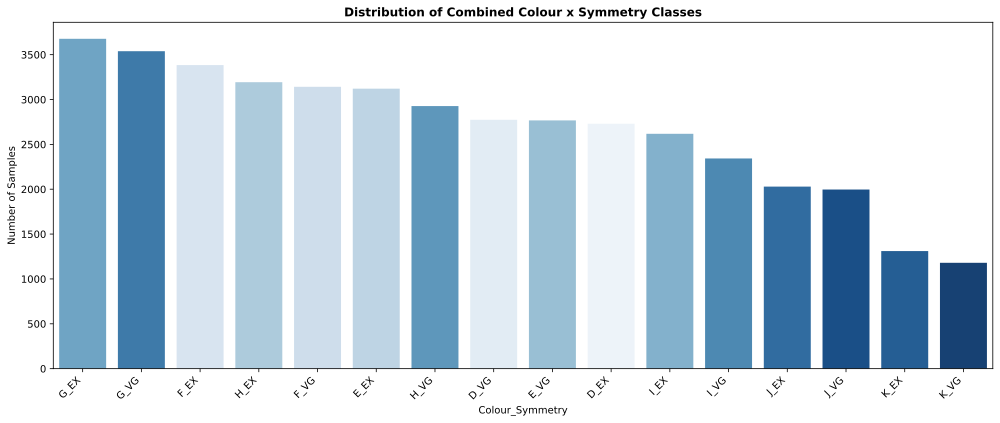

In [26]:
import matplotlib.pyplot as plt
import seaborn as sns

# Print raw class counts for the combined colour-symmetry label
print("\n---  Diamond Colour x Symmetry Classes ---")
print(df_filtered['colour_symmetry'].value_counts())

# Visualize the class distribution as a bar plot, ordered by frequency
plt.figure(figsize=(14, 6))
order = df_filtered['colour_symmetry'].value_counts().index
sns.countplot(
    data=df_filtered,
    x='colour_symmetry',
    order=order,
    hue='colour_symmetry',
    palette='Blues_r',
    legend=False
)
plt.title('Distribution of Combined Colour x Symmetry Classes', fontweight='bold', fontsize=12)
plt.xlabel('Colour_Symmetry')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

## 3. Custom Dataset & DataLoader

I now build the data pipeline for the combined colour-symmetry task: a custom `Dataset` class that lazy-loads images and maps their combined colour-symmetry label to an integer class ID, and the corresponding `DataLoader` objects for batch training. Since the combined label was already split in a stratified manner, I compute the list of possible classes once on the full filtered dataset, before splitting, to guarantee that both the training and test `Dataset` objects use identical label mappings.

In [27]:
import os
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from PIL import Image

# 1. Define the Data Preprocessing Pipeline
# - Resize: Enforces a uniform spatial resolution (96x96), required as input size for GoogLeNet.
# - ToTensor: Converts the PIL Image into a 32-bit floating-point PyTorch tensor
#   and normalizes the pixel intensity values from [0, 255] to the [0.0, 1.0] range.
data_transforms_cross = transforms.Compose([
    transforms.Resize((96, 96)),
    transforms.ToTensor()
])

# 2. Compute the combined class list once on the full filtered dataset, before splitting,
# to guarantee consistent label indices between train and test sets.
cross_classes = sorted(df_filtered['colour_symmetry'].unique())

# 3. Custom Dataset Implementation
class DiamondCross(Dataset):
    """
    Custom PyTorch Dataset class designed to lazy-load diamond images and their
    corresponding combined colour-symmetry target labels from the local filesystem.
    """
    def __init__(self, dataframe, base_dir, classes, transform=None):
        # Reset index to ensure sequential access without index gaps
        self.data = dataframe.reset_index(drop=True)
        self.base_dir = base_dir
        self.transform = transform
        # Label Encoding: Dynamically build a mapping dictionary from
        # categorical string labels to discrete integer class IDs (0, 1, 2, ... N-1).
        # This is mathematically required by the CrossEntropyLoss function.
        self.classes = classes
        self.class_map = {name: i for i, name in enumerate(self.classes)}

    def __len__(self):
        """
        Returns the total number of samples in the dataset.
        Crucial for the DataLoader to determine epoch boundaries.
        """
        return len(self.data)

    def __getitem__(self, idx):
        """
        Fetches the sample at the specified index.
        Implements a lazy-loading paradigm to minimize RAM consumption.
        """
        # Construct the absolute file path by joining the local base directory
        # with the relative path extracted from the DataFrame
        rel_path = str(self.data.iloc[idx]['path_to_img'])
        img_path = os.path.join(self.base_dir, rel_path)
        # Load the image from disk and strictly convert it to the RGB color space
        # (dropping potential alpha channels that would break tensor dimensions)
        image = Image.open(img_path).convert('RGB')
        # Apply the defined torchvision transformations
        if self.transform:
            image = self.transform(image)
        # Extract the categorical string label and map it to its corresponding integer ID.
        # It is cast to a torch.long tensor, which is the required datatype for classification targets.
        label = torch.tensor(self.class_map[self.data.iloc[idx]['colour_symmetry']], dtype=torch.long)
        return image, label

# 4. Instantiate the Custom Datasets
# Bind the cleaned dataframes to our custom Dataset class, pointing to the fast local storage
train_dataset_cross = DiamondCross(train_df_cross, local_dir, cross_classes, transform=data_transforms_cross)
test_dataset_cross = DiamondCross(test_df_cross, local_dir, cross_classes, transform=data_transforms_cross)

# 5. Configure DataLoaders for Batch Generation
# A batch size of 128 optimally utilizes the T4 GPU's VRAM for parallel matrix multiplication
batch_size = 128

# Instantiate PyTorch DataLoaders.
# shuffle=True for training prevents the model from learning sequential biases.
# num_workers=2 enables multiprocessing to prepare batches in the background.
train_iter_cross = DataLoader(train_dataset_cross, batch_size=batch_size, shuffle=True, num_workers=2)
test_iter_cross = DataLoader(test_dataset_cross, batch_size=batch_size, shuffle=False, num_workers=2)

## 4. Convolutional Neural Network Architecture — GoogLeNet

For the combined colour-symmetry task, I reuse the same GoogLeNet architecture designed for the colour task. However, since `b1` to `b5` are stateful PyTorch modules already bound (with their own trained weights) to `net_colour`, I redefine the `Inception` blocks and the sequential blocks from scratch here, so that `net_cross` has its own independent set of parameters and does not share weights with `net_colour`. Only the final fully connected layer differs in size, outputting a prediction over the 16 combined colour-symmetry classes instead of 8.

In [28]:
import torch
import torch.nn as nn
from torch.nn import functional as F

class InceptionCross(nn.Module):
    def __init__(self, in_channels, c1, c2, c3, c4, **kwargs):
        super(InceptionCross, self).__init__(**kwargs)
        self.p1_1 = nn.Conv2d(in_channels, c1, kernel_size=1)
        self.p2_1 = nn.Conv2d(in_channels, c2[0], kernel_size=1)
        self.p2_2 = nn.Conv2d(c2[0], c2[1], kernel_size=3, padding=1)
        self.p3_1 = nn.Conv2d(in_channels, c3[0], kernel_size=1)
        self.p3_2 = nn.Conv2d(c3[0], c3[1], kernel_size=5, padding=2)
        self.p4_1 = nn.MaxPool2d(kernel_size=3, stride=1, padding=1)
        self.p4_2 = nn.Conv2d(in_channels, c4, kernel_size=1)

    def forward(self, x):
        p1 = F.relu(self.p1_1(x))
        p2 = F.relu(self.p2_2(F.relu(self.p2_1(x))))
        p3 = F.relu(self.p3_2(F.relu(self.p3_1(x))))
        p4 = F.relu(self.p4_2(self.p4_1(x)))
        return torch.cat((p1, p2, p3, p4), dim=1)

# GoogLeNet modules (independent instance, adapted for 3-channel RGB images)
b1_cross = nn.Sequential(
    nn.Conv2d(3, 64, kernel_size=7, stride=2, padding=3),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)
b2_cross = nn.Sequential(
    nn.Conv2d(64, 64, kernel_size=1),
    nn.ReLU(),
    nn.Conv2d(64, 192, kernel_size=3, padding=1),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)
b3_cross = nn.Sequential(
    InceptionCross(192, 64, (96, 128), (16, 32), 32),
    InceptionCross(256, 128, (128, 192), (32, 96), 64),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)
b4_cross = nn.Sequential(
    InceptionCross(480, 192, (96, 208), (16, 48), 64),
    InceptionCross(512, 160, (112, 224), (24, 64), 64),
    InceptionCross(512, 128, (128, 256), (24, 64), 64),
    InceptionCross(512, 112, (144, 288), (32, 64), 64),
    InceptionCross(528, 256, (160, 320), (32, 128), 128),
    nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
)
b5_cross = nn.Sequential(
    InceptionCross(832, 256, (160, 320), (32, 128), 128),
    InceptionCross(832, 384, (192, 384), (48, 128), 128),
    nn.AdaptiveAvgPool2d((1, 1)),
    nn.Flatten()
)

# Final GoogLeNet model adapted for 16 combined colour-symmetry classes
net_cross = nn.Sequential(b1_cross, b2_cross, b3_cross, b4_cross, b5_cross, nn.Linear(1024, 16))

## 5. Model Training & Validation Execution

I now train the GoogLeNet model on the combined colour-symmetry task, reusing the same generic `train` function defined earlier. I use the same hyperparameters as the colour task (learning rate `0.01`, 10 epochs), tracking both training and validation accuracy at each epoch. Once training completes, I save the model's weights directly to Google Drive for persistence across sessions.


✅ Training Completed:
Final Training Loss: 1.998
Final Training Accuracy: 0.275
Final Validation Accuracy: 0.137
✅ GoogLeNet colour x symmetry model successfully saved to: /content/drive/MyDrive/Progetto diamanti /modello_cross_googlenet.pth


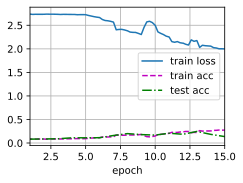

In [30]:
from d2l import torch as d2l
import os

# Training hyperparameters
lr, num_epochs = 0.01, 15

# Start training with GoogLeNet
train(net_cross, train_iter_cross, test_iter_cross, num_epochs, lr, device=d2l.try_gpu())

# Save weights to Google Drive
model_save_path = os.path.join(base_dir, 'modello_cross_googlenet.pth')
torch.save(net_cross.state_dict(), model_save_path)
print(f"✅ GoogLeNet colour x symmetry model successfully saved to: {model_save_path}")

## 6. Model Evaluation

After training, I evaluate the GoogLeNet model's per-class performance on the combined colour-symmetry task by running inference over the entire validation set and computing precision, recall and f1-score for each of the 16 combined classes.

In [31]:
# Evaluate the trained model on the entire validation set and generate
# a per-class classification report (precision, recall, f1-score) for the colour x symmetry task.

import torch
from sklearn.metrics import classification_report

device = next(net_cross.parameters()).device
net_cross.eval()

# Lists to accumulate all predictions and ground-truth labels for the cross task
all_preds_cross = []
all_labels_cross = []


with torch.no_grad():
    for X, y in test_iter_cross:
        X = X.to(device)
        y_hat = net_cross(X)
        preds = torch.argmax(y_hat, dim=1)
        all_preds_cross.extend(preds.cpu().numpy())
        all_labels_cross.extend(y.numpy())

# Retrieve the class names from the test dataset
cross_classes = list(test_dataset_cross.classes)

# --- TEXT REPORT ---
print("\n" + "="*60)
print("DIAMOND CROSS CLASSIFICATION (Colour x Symmetry) - REPORT")
print("="*60)
print(classification_report(all_labels_cross, all_preds_cross, target_names=cross_classes))


DIAMOND CROSS CLASSIFICATION (Colour x Symmetry) - REPORT
              precision    recall  f1-score   support

        D_EX       0.10      0.28      0.15       546
        D_VG       0.17      0.95      0.29       555
        E_EX       0.20      0.07      0.11       624
        E_VG       0.04      0.03      0.03       553
        F_EX       0.05      0.04      0.04       677
        F_VG       0.07      0.07      0.07       628
        G_EX       0.05      0.03      0.03       736
        G_VG       0.11      0.06      0.08       708
        H_EX       0.06      0.03      0.04       639
        H_VG       0.14      0.05      0.07       585
        I_EX       0.08      0.01      0.02       524
        I_VG       0.20      0.13      0.15       469
        J_EX       0.18      0.06      0.09       406
        J_VG       0.27      0.25      0.26       399
        K_EX       0.59      0.08      0.15       262
        K_VG       0.53      0.18      0.27       236

    accuracy         

## 7. Confusion Matrix

To better visualize where the model confuses adjacent colour-symmetry combinations, I plot the confusion matrix using the predictions and ground-truth labels computed in the previous step. Given the higher number of classes (16), I omit the per-cell numeric annotations to keep the plot readable.

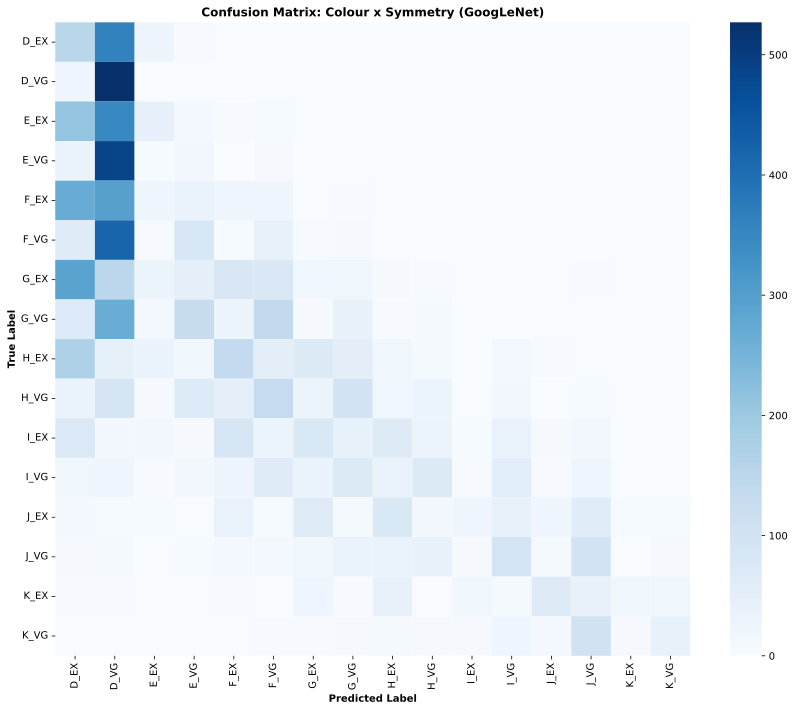

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
import seaborn as sns

cm_cross = confusion_matrix(all_labels_cross, all_preds_cross)

plt.figure(figsize=(12, 10))
sns.heatmap(cm_cross, annot=False, fmt='d', cmap='Blues',
            xticklabels=cross_classes, yticklabels=cross_classes)
plt.title('Confusion Matrix: Colour x Symmetry (GoogLeNet)', fontweight='bold', fontsize=12)
plt.ylabel('True Label', fontweight='bold')
plt.xlabel('Predicted Label', fontweight='bold')
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

## 8. Qualitative Check

As a final sanity check, I pick a random test image and visually compare the model's combined colour-symmetry prediction against the true label.

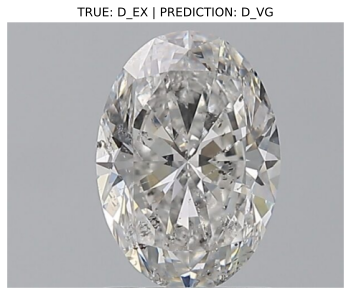

In [33]:
# Pick a random test image and visually compare the model's colour-symmetry prediction
# against the true label, as a quick qualitative sanity check.

def predict_random_image_cross():
    net_cross.eval()
    sample_row = test_df_cross.sample(1).iloc[0]
    img_path = os.path.join(local_dir, sample_row['path_to_img'])
    img = Image.open(img_path).convert('RGB')

    img_tensor = data_transforms_cross(img).unsqueeze(0).to(device)

    with torch.no_grad():
        output = net_cross(img_tensor)
        predicted_idx = torch.argmax(output, dim=1)

    predicted_cross = test_dataset_cross.classes[predicted_idx.item()]
    true_cross = sample_row['colour_symmetry']

    plt.imshow(img)
    plt.title(f"TRUE: {true_cross} | PREDICTION: {predicted_cross}")
    plt.axis('off')
    plt.show()

predict_random_image_cross()